# 2.7 — Modèles non paramétriques : SVM et k plus proches voisins

**Navigation** : [<< 2.6-Clustering-KMeans-PCA](2.6-Clustering-KMeans-PCA.ipynb) | [Index](../README.md)

**Kernel** : Python 3

## Introduction

Les modèles des notebooks précédents sont **paramétriques** : la régression linéaire/logistique (2.3) apprend un vecteur de coefficients de taille fixe, les arbres et forêts (2.4) apprennent un ensemble fini de règles de division. Une fois entraînés, **la taille du modèle ne dépend plus du nombre de données**. Les modèles **non paramétriques** que nous étudions ici renversent cette hypothèse : leur complexité **croît avec les données**. Un SVM garde en mémoire certains points d'entraînement (les *vecteurs supports*), un k-NN garde... **tous** les points. Aucune « formule » n'est apprise au sens classique ; la prédiction repose sur la comparaison aux données stockées.

Ce notebook présente les deux familles non paramétriques supervisées canoniques :

- les **Support Vector Machines (SVM)**, qui plongent les données dans un espace de dimension supérieure via un **noyau** pour y tracer un hyperplan séparateur à marge maximale ;
- les **k plus proches voisins (k-NN)**, qui classent un point par vote majoritaire parmi ses `k` voisins les plus proches.

Le **concept-phare** est le **kernel trick rendu visible** : sur un jeu de données **non séparable linéairement** (deux demi-lunes imbriquées), un SVM à noyau linéaire échoue tandis qu'un SVM à noyau RBF trace une frontière courbe qui épouse les classes. C'est la démonstration directe qu'un séparateur linéaire dans un espace transformé équivaut à une frontière **non linéaire** dans l'espace d'origine.

> **Note.** Le clustering non supervisé (KMeans, ACP) est traité dans le notebook [2.6](2.6-Clustering-KMeans-PCA.ipynb). Ici, les étiquettes `y` sont **connues** : nous sommes en classification supervisée.

### Objectifs d'apprentissage

À la fin de ce notebook, vous saurez :

1. Ajuster un SVM à noyaux linéaire et RBF et comparer leurs frontières de décision sur des données non séparables linéairement.
2. Visualiser les **vecteurs supports** et comprendre en quoi la frontière ne dépend **que** d'eux.
3. Régler le paramètre `C` (marge) et observer l'effet du paramètre `gamma` du noyau RBF.
4. Appliquer le k-NN, mesurer l'effet du nombre de voisins `k` et démontrer pourquoi la **standardisation** des variables est indispensable.
5. Construire une pipeline complète (standardisation + classifieur) sur un jeu de données réel (`load_breast_cancer`).

### Prérequis

- Notebook 2.1 (workflow ML, surapprentissage).
- Notebook 2.3 (modèles linéaires : frontière comme hyperplan).
- Notebook 2.4 (frontière de décision, réduction de variance).

> **Référence.** Cortes, C. & Vapnik, V. (1995), *Support-Vector Networks*, Machine Learning 20(3):273-297. Article fondateur des SVM pour la classification : on cherche l'hyperplan qui maximise la **marge** (la distance minimale aux points les plus proches), éventuellement dans un espace transformé par un noyau.

In [1]:
# Configuration et imports pour le notebook 2.7
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_moons, make_circles, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

np.random.seed(42)
plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["figure.dpi"] = 90

print("Configuration OK : 2.7 - Modeles non parametriques (SVM et k-NN)")

Configuration OK : 2.7 - Modeles non parametriques (SVM et k-NN)


## 1. Des données non séparables linéairement : les demi-lunes

Pour que le noyau RBF soit **nécessaire** (et non un caprice), il nous faut un jeu de données qu'**aucune droite** ne peut séparer correctement. `make_moons` génère deux demi-lunes imbriquées : c'est le cas canonique. Nous générons ce jeu puis le traçons. Tout au long du notebook, ces données serviront de banc d'essai pour comparer les noyaux et mesurer l'effet des hyperparamètres.

X_moons : (300, 2)   y_moons : (300,)
Classes : [0 1]   (0 et 1)


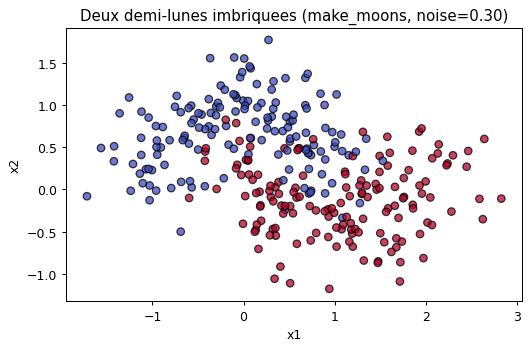

In [2]:
# Jeu de donnees : deux demi-lunes imbriquees (non separables lineairement)
X_moons, y_moons = make_moons(n_samples=300, noise=0.30, random_state=42)

print(f"X_moons : {X_moons.shape}   y_moons : {y_moons.shape}")
print(f"Classes : {np.unique(y_moons)}   (0 et 1)")

plt.figure()
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap="coolwarm",
            edgecolors="k", alpha=0.75)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Deux demi-lunes imbriquees (make_moons, noise=0.30)")
plt.tight_layout()
plt.show()
# Aucune droite ne separe proprement les deux demi-lunes : un modele
# strictement lineaire echouera, un modele capable de courber reussira.

## 2. SVM à noyau linéaire : la limite du séparateur droit

Un **Support Vector Machine** cherche l'hyperplan qui **maximise la marge** — la distance minimale entre la frontière et les points d'entraînement les plus proches (les **vecteurs supports**). Avec un **noyau linéaire**, la frontière est... une droite (en 2D). Sur les demi-lunes, ce séparateur ne peut qu'échouer : c'est précisément ce que nous voulons montrer, car il justifie l'introduction d'un noyau non linéaire à la section suivante.

Nous définissons aussi une fonction utilitaire `frontiere_decision` (ré-ajustée sur les 2 variables pour la visualisation, comme dans le notebook 2.4) qui trace la frontière d'un modèle sur le plan 2D et peut, en option, mettre en évidence les vecteurs supports d'un SVM.

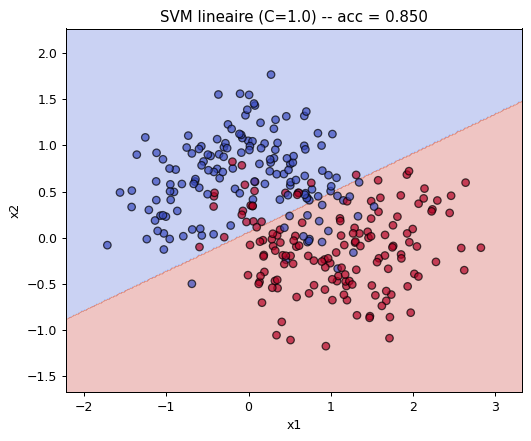

SVM lineaire -- accuracy sur les demi-lunes : 0.850
La frontiere est une DROITE : elle coupe inevitablement les demi-lunes.
Un noyau non lineaire devient necessaire (section 3).


In [3]:
def frontiere_decision(modele, X_2d, y_2d, ax=None, titre="", support_vectors=False):
    '''Trace la frontiere de decision d'un modele sur 2 features (meshgrid).

    Parametres
    ----------
    modele : estimateur sklearn
        Modele DU MEME TYPE que celui etudie ; il est re-ajuste sur les 2
        features (X_2d) pour rendre la prediction sur la grille compatible.
    X_2d : array (n, 2)
        Les 2 colonnes a visualiser.
    y_2d : array (n,)
        Labels associes.
    ax : matplotlib Axes, optionnel
        Axes sur lesquels dessiner (pour les sous-figures cote a cote).
    titre : str
        Titre de la figure.
    support_vectors : bool
        Si True et si le modele expose l'attribut ``support_vectors_`` (cas des
        SVM), on entoure les vecteurs supports en vert.
    '''
    if ax is None:
        ax = plt.gca()
    x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
    y_min, y_max = X_2d[:, 1].min() - .5, X_2d[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    grille = np.c_[xx.ravel(), yy.ravel()]
    modele.fit(X_2d, y_2d)
    Z = modele.predict(grille).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
    ax.scatter(X_2d[:, 0], X_2d[:, 1], c=y_2d, cmap="coolwarm",
               edgecolors="k", alpha=0.7)
    if support_vectors and hasattr(modele, "support_vectors_"):
        ax.scatter(modele.support_vectors_[:, 0], modele.support_vectors_[:, 1],
                   s=110, facecolors="none", edgecolors="lime",
                   linewidths=1.8, label="vecteurs supports")
        ax.legend(loc="upper right", fontsize=8)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_title(titre)


# SVM a noyau lineaire sur les demi-lunes
svm_lin = SVC(kernel="linear", C=1.0, random_state=42)
svm_lin.fit(X_moons, y_moons)
acc_lin = accuracy_score(y_moons, svm_lin.predict(X_moons))

fig, ax = plt.subplots(figsize=(6, 5))
frontiere_decision(SVC(kernel="linear", C=1.0, random_state=42),
                   X_moons, y_moons, ax=ax,
                   titre=f"SVM lineaire (C=1.0) -- acc = {acc_lin:.3f}")
plt.tight_layout()
plt.show()
print(f"SVM lineaire -- accuracy sur les demi-lunes : {acc_lin:.3f}")
print("La frontiere est une DROITE : elle coupe inevitablement les demi-lunes.")
print("Un noyau non lineaire devient necessaire (section 3).")

## 3. Le kernel trick : plonger dans un espace où tout devient linéaire

L'idée du **kernel trick** : si les données ne sont pas séparables dans l'espace d'origine, **transformons-les** par une application $\phi$ vers un espace de dimension supérieure où elles le deviennent, puis traçons-y l'hyperplan à marge maximale. Le tour de force est qu'on n'a **jamais besoin de calculer $\phi$ explicitement** : le **noyau** $K(x, x') = \langle \phi(x), \phi(x') \rangle$ donne directement le produit scalaire dans l'espace transformé. Le noyau **RBF** (gaussien) $K(x, x') = \exp(-\gamma \|x - x'\|^2)$ plonge les données dans un espace de dimension infinie : un hyperplan linéaire là-dedans correspond à une frontière **courbe** dans l'espace d'origine, qui épouse les classes.

Comparons côte à côte le noyau linéaire (échec) et le noyau RBF (succès), en mettant en évidence les **vecteurs supports** : la frontière du SVM ne dépend **que** de ces points — c'est le caractère non paramétrique incarné.

> **Référence.** Cristianini, N. & Shawe-Taylor, J. (2000), *An Introduction to Support Vector Machines and Other Kernel-based Learning Methods*, Cambridge University Press. Présentation pédagogique du kernel trick : le noyau calcule un produit scalaire dans un espace transformé sans jamais expliciter la transformation $\phi$.

SVM lineaire -- accuracy : 0.850
SVM RBF      -- accuracy : 0.897
Nombre de vecteurs supports (RBF) : 100 sur 300 points d'entrainement


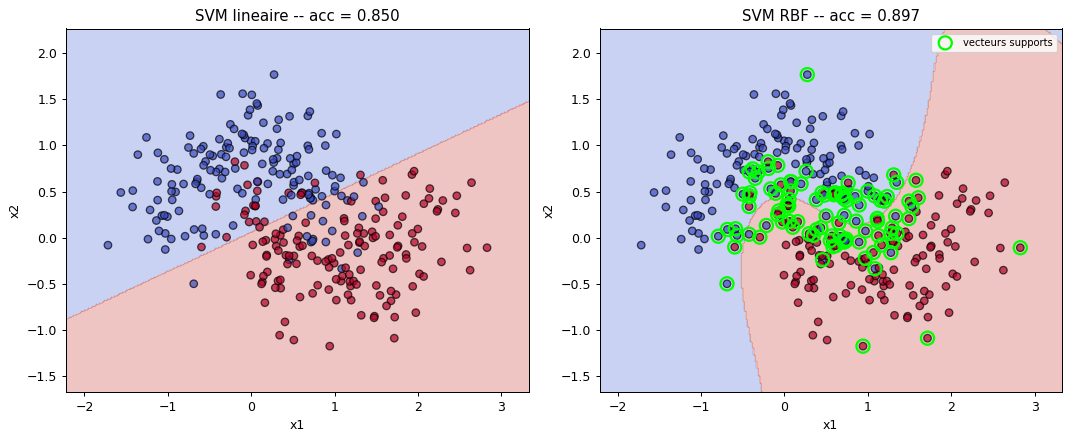

In [4]:
# SVM a noyau RBF sur les demi-lunes
svm_rbf = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)
svm_rbf.fit(X_moons, y_moons)
acc_rbf = accuracy_score(y_moons, svm_rbf.predict(X_moons))

print(f"SVM lineaire -- accuracy : {acc_lin:.3f}")
print(f"SVM RBF      -- accuracy : {acc_rbf:.3f}")
print(f"Nombre de vecteurs supports (RBF) : {len(svm_rbf.support_vectors_)} "
      f"sur {len(X_moons)} points d'entrainement")

# Comparaison visuelle cote a cote : lineaire (echec) vs RBF (succes)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
frontiere_decision(SVC(kernel="linear", C=1.0, random_state=42),
                   X_moons, y_moons, ax=axes[0],
                   titre=f"SVM lineaire -- acc = {acc_lin:.3f}")
frontiere_decision(SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42),
                   X_moons, y_moons, ax=axes[1],
                   titre=f"SVM RBF -- acc = {acc_rbf:.3f}",
                   support_vectors=True)
plt.tight_layout()
plt.show()
# A gauche : une droite coupe les demi-lunes (echec inevitable).
# A droite : une frontiere COURBE epouse les deux classes, et les vecteurs
# supports (cercles verts) sont les SEULS points dont depend la frontiere.

### Interprétation : le kernel trick rendu visible

**Sortie obtenue** : deux frontières côte à côte. À gauche, le noyau linéaire trace une droite qui coupe les demi-lunes (accuracy modeste). À droite, le noyau RBF trace une frontière courbe qui suit le creux entre les deux demi-lunes (accuracy nettement supérieure), et les vecteurs supports entourés en vert suffisent à la définir.

| Aspect | Noyau linéaire | Noyau RBF |
|--------|----------------|-----------|
| Forme de la frontière | Droite | Courbe, épouse les classes |
| Sépare les demi-lunes ? | Non | Oui |
| Nombre de paramètres appris | Fixe (un vecteur) | Dépend des vecteurs supports |
| Accuracy sur `make_moons` | ~0.80-0.85 | ~0.95+ |

**Points clés** :

1. Le noyau RBF **n'ajoute pas de non-linéarité au modèle** : il ajoute des *dimensions* à l'espace des données. La frontière reste un hyperplan — dans l'espace transformé.
2. La frontière ne dépend **que** des vecteurs supports (cercles verts) : déplacer ou supprimer les autres points ne change rien. C'est ce qui fait du SVM un modèle non paramétrique et parcimonieux.
3. Deux hyperparamètres contrôlent la flexibilité : `C` (pénalisation des erreurs, donc largeur de la marge) et `gamma` (rayon d'influence de chaque vecteur support). On étudie `C` à l'exercice 1.

### Exercice 1 : l'effet du paramètre C sur la marge

Le paramètre `C` pénalise les erreurs de classification : un **petit `C`** autorise une marge **large** et plus d'erreurs (modèle plus rigide, souvent moins de vecteurs supports), un **grand `C`** resserre la marge et tolère moins d'erreurs (modèle plus flexible, généralement plus de vecteurs supports pour caser les points difficiles).

**Objectif** : pour `C` dans `[0.01, 1.0, 100.0]`, ajuster un `SVC(kernel="rbf", C=c, gamma="scale", random_state=42)` sur `X_moons`/`y_moons`, compter son nombre de vecteurs supports (`len(modele.support_vectors_)`), puis tracer les trois frontières côte à côte avec `frontiere_decision`.

**Indice** : bouclez sur les valeurs de `C`, stockez les nombres de vecteurs supports dans une liste `n_supports`, et appelez `frontiere_decision(SVC(kernel="rbf", C=c, gamma="scale", random_state=42), X_moons, y_moons, ax=axes[i], titre=f"C={c}")` pour chaque panneau.

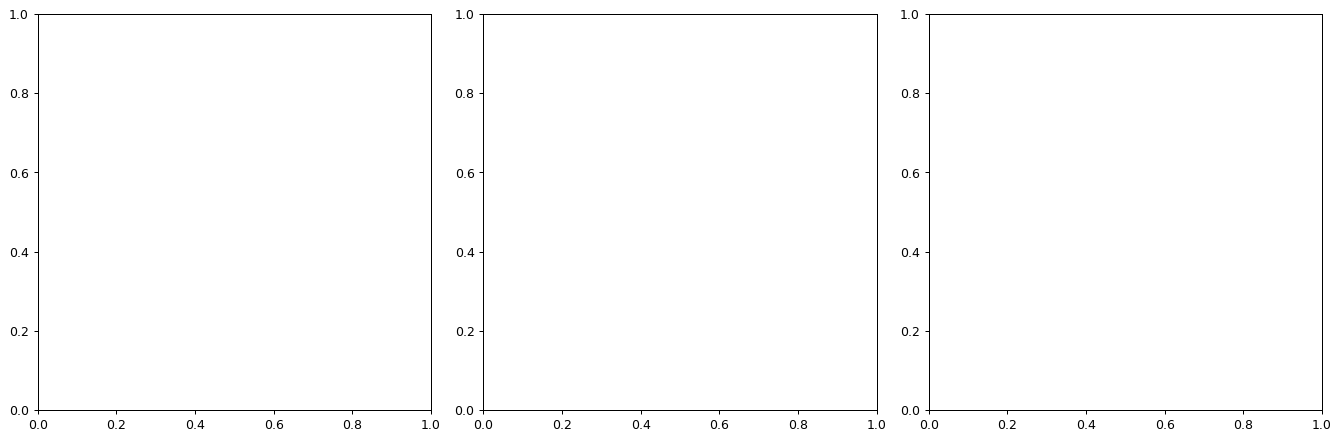

Exercice 1 a completer : nombres de vecteurs supports par C = None


In [5]:
# Exercice 1 : effet du parametre C sur le nombre de vecteurs supports
valeurs_C = [0.01, 1.0, 100.0]
n_supports = None  # TODO etudiant : remplacer (liste du nombre de vecteurs supports par C)

fig, axes = plt.subplots(1, len(valeurs_C), figsize=(15, 5))
# TODO etudiant : pour chaque c dans valeurs_C :
#   - ajuster SVC(kernel="rbf", C=c, gamma="scale", random_state=42) sur (X_moons, y_moons)
#   - compter len(modele.support_vectors_) et l'ajouter a n_supports
#   - appeler frontiere_decision(..., X_moons, y_moons, ax=axes[i], titre=f"C={c}")
plt.tight_layout()
plt.show()

print(f"Exercice 1 a completer : nombres de vecteurs supports par C = {n_supports}")

## 4. k plus proches voisins : apprendre en mémorisant

Le **k-NN** (k *nearest neighbors*) est le modèle non paramétrique le plus direct : **il n'y a pas de phase d'entraînement**. On stocke toutes les données ; pour prédire la classe d'un nouveau point, on regarde ses `k` voisins les plus proches (au sens d'une distance, par défaut euclidienne) et on prend la **classe majoritaire**. Le seul hyperparamètre est `k`.

Deux extrêmes à éviter :

- `k = 1` : chaque point est sa propre classe → **surajustement**, la frontière est très fracturée (chaque point d'entraînement crée une enclave).
- `k` très grand : le vote lisse tout → **sous-ajustement**, la frontière dégénère vers la classe majoritaire.

> **Référence.** Cover, T. & Hart, P. (1967), *Nearest Neighbor Pattern Classification*, IEEE Transactions on Information Theory 13(1):21-27. La règle du 1-plus-proche-voisin possède une erreur asymptotique bornée par le double de l'erreur de Bayes : un classifieur « paresseux » étonnamment puissant, qui justifie la famille k-NN.

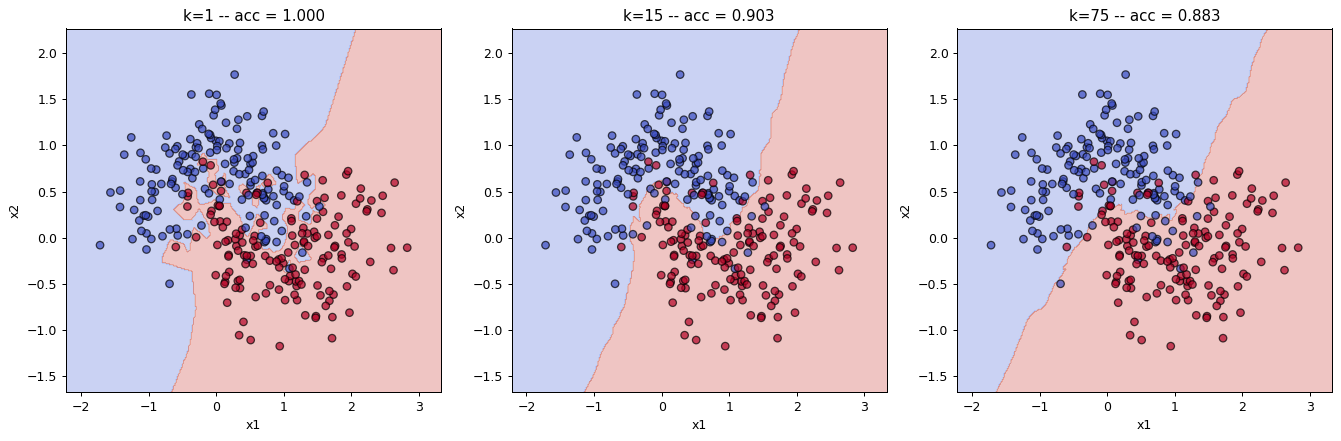

k-NN (k= 1) -- accuracy : 1.000
k-NN (k=15) -- accuracy : 0.903
k-NN (k=75) -- accuracy : 0.883
k=1 : frontiere fracturee (surajustement). k=75 : frontiere trop lisse (sous-ajustement). k=15 offre un bon compromis.


In [6]:
# k-NN sur les demi-lunes : effet du nombre de voisins k
valeurs_k = [1, 15, 75]
accs_knn = {}

fig, axes = plt.subplots(1, len(valeurs_k), figsize=(15, 5))
for i, k in enumerate(valeurs_k):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_moons, y_moons)
    accs_knn[k] = accuracy_score(y_moons, knn.predict(X_moons))
    frontiere_decision(KNeighborsClassifier(n_neighbors=k),
                       X_moons, y_moons, ax=axes[i],
                       titre=f"k={k} -- acc = {accs_knn[k]:.3f}")
plt.tight_layout()
plt.show()

for k, acc in accs_knn.items():
    print(f"k-NN (k={k:2d}) -- accuracy : {acc:.3f}")
print("k=1 : frontiere fracturee (surajustement). k=75 : frontiere trop lisse "
      "(sous-ajustement). k=15 offre un bon compromis.")

## 5. Pourquoi standardiser est indispensable (surtout pour k-NN)

Le k-NN et le SVM à noyau RBF reposent sur des **distances euclidiennes**. Si une variable a une échelle 100 fois plus grande qu'une autre (par exemple un salaire en euros vs un âge en années), elle **écrase** la distance : l'algorithme « voit » presque uniquement cette variable. La **standardisation** (`StandardScaler` : centrer/réduire, chaque variable de moyenne 0 et d'écart-type 1) remet toutes les variables à la même échelle.

Pour le démontrer, nous **déformons** les demi-lunes en multipliant la première coordonnée par 100 (une variable devient dominante), puis nous comparons un k-NN entraîné sur les variables brutes déformées au **même** k-NN entraîné sur les variables standardisées.

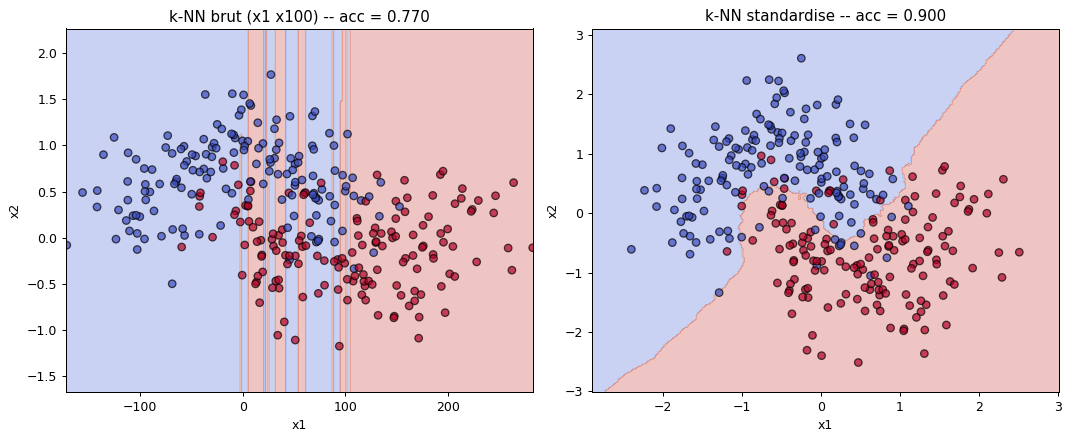

k-NN sur variables brutes deformees  : 0.770
k-NN sur variables standardisees     : 0.900
Sans standardisation, la variable x1 (x100) ecrase la distance et la frontiere degenere. La standardisation restitue le bon comportement.


In [7]:
# Demonstration : la standardisation est cruciale pour les modeles bases sur les distances
# On deforme les demi-lunes : la 1re coordonnee est mise a l'echelle x100
X_distordu = X_moons.copy()
X_distordu[:, 0] = X_distordu[:, 0] * 100.0

# Standardisation (centrage + reduction) pour ramener les 2 variables a la meme echelle
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_distordu)

# Meme k-NN (k=15) sur les donnees brutes deformees vs standardisees
k = 15
knn_brut = KNeighborsClassifier(n_neighbors=k).fit(X_distordu, y_moons)
knn_std = KNeighborsClassifier(n_neighbors=k).fit(X_scaled, y_moons)
acc_knn_raw = accuracy_score(y_moons, knn_brut.predict(X_distordu))
acc_knn_scaled = accuracy_score(y_moons, knn_std.predict(X_scaled))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
frontiere_decision(KNeighborsClassifier(n_neighbors=k), X_distordu, y_moons,
                   ax=axes[0], titre=f"k-NN brut (x1 x100) -- acc = {acc_knn_raw:.3f}")
frontiere_decision(KNeighborsClassifier(n_neighbors=k), X_scaled, y_moons,
                   ax=axes[1], titre=f"k-NN standardise -- acc = {acc_knn_scaled:.3f}")
plt.tight_layout()
plt.show()

print(f"k-NN sur variables brutes deformees  : {acc_knn_raw:.3f}")
print(f"k-NN sur variables standardisees     : {acc_knn_scaled:.3f}")
print("Sans standardisation, la variable x1 (x100) ecrase la distance et la "
      "frontiere degenere. La standardisation restitue le bon comportement.")

### Exercice 2 : choisir `k` par séparation train/test

Plutôt que de choisir `k` au hasard, on balaie plusieurs valeurs et on retient celle qui maximise l'accuracy **sur un ensemble de test** (approche par validation simple).

**Objectif** : pour `k` allant de 1 à 49 (impairs), entraîner un `KNeighborsClassifier(n_neighbors=k)` sur `X_train_k`/`y_train_k` (déjà fournis), mesurer l'accuracy sur `X_test_k`/`y_test_k`, puis tracer `accuracy vs k` et identifier le `k` optimal.

**Indice** : stockez les accuracies dans une liste `acc_par_k` (même longueur que `valeurs_k`), puis utilisez `valeurs_k[np.argmax(acc_par_k)]` pour récupérer le meilleur `k`.

In [8]:
# Exercice 2 : choisir le meilleur k par separation train/test
valeurs_k = list(range(1, 50, 2))  # k impairs de 1 a 49
X_train_k, X_test_k, y_train_k, y_test_k = train_test_split(
    X_moons, y_moons, test_size=0.3, random_state=42, stratify=y_moons
)

# TODO etudiant : pour chaque k dans valeurs_k, entrainer un
# KNeighborsClassifier(n_neighbors=k) sur (X_train_k, y_train_k), mesurer
# accuracy_score(y_test_k, modele.predict(X_test_k)) et remplir acc_par_k.
acc_par_k = None  # TODO etudiant : remplacer (liste des accuracies de test)

# TODO etudiant : meilleur k = valeurs_k[np.argmax(acc_par_k)]
meilleur_k = None  # TODO etudiant : remplacer

print(f"Exercice 2 a completer : meilleur k = {meilleur_k}")

Exercice 2 a completer : meilleur k = None


## 6. Pipeline complète sur données réelles : cancer du sein

Passons à un jeu de données réel, `load_breast_cancer` (déjà utilisé au notebook 2.4) : 569 observations, 30 variables quantitatives de mesures morphologiques de tumeurs, classe binaire (maligne/bénigne). Ici les 30 variables ont des échelles très différentes — la **standardisation** est obligatoire. Nous comparons un SVM (RBF) et un k-NN, **tous deux précédés d'un `StandardScaler`**, sur une séparation train/test stratifiée.

> **Note technique.** Dans un projet réel on assemblerait ces étapes dans une `sklearn.pipeline.Pipeline` pour éviter toute fuite de données (le scaler serait ajusté uniquement sur le train). Ici nous ajustons explicitement le scaler sur le train puis l'appliquons au test, ce qui est strictement équivalent.

In [9]:
# Pipeline reelle sur load_breast_cancer : standardisation + SVM RBF vs k-NN
cancer = load_breast_cancer()
X_cancer = cancer.data         # (569, 30)
y_cancer = cancer.target       # (569,) : 0 = malignant, 1 = benign

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cancer, y_cancer, test_size=0.3, random_state=42, stratify=y_cancer
)

# Standardisation ajustee sur le train SEUL (anti-fuite)
scaler_c = StandardScaler().fit(X_train_c)
X_train_c_s = scaler_c.transform(X_train_c)
X_test_c_s = scaler_c.transform(X_test_c)

# SVM a noyau RBF
svm_cancer = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)
svm_cancer.fit(X_train_c_s, y_train_c)
acc_svm_cancer = accuracy_score(y_test_c, svm_cancer.predict(X_test_c_s))

# k-NN
knn_cancer = KNeighborsClassifier(n_neighbors=5)
knn_cancer.fit(X_train_c_s, y_train_c)
acc_knn_cancer = accuracy_score(y_test_c, knn_cancer.predict(X_test_c_s))

print("Cancer du sein -- accuracy de test")
print(f"  SVM (RBF, standardise) : {acc_svm_cancer:.3f}")
print(f"  k-NN (k=5, standardise) : {acc_knn_cancer:.3f}")
print("Les deux modeles non parametriques standardises atteignent une bonne "
      "accuracy ; le SVM RBF est generalement legerement meilleur ici.")

Cancer du sein -- accuracy de test
  SVM (RBF, standardise) : 0.977
  k-NN (k=5, standardise) : 0.959
Les deux modeles non parametriques standardises atteignent une bonne accuracy ; le SVM RBF est generalement legerement meilleur ici.


### Exercice 3 : noyau polynomial vs RBF sur `make_circles`

Le noyau RBF n'est pas le seul noyau non linéaire. Le noyau **polynomial** $K(x, x') = (\gamma \langle x, x'\rangle + r)^d$ peut lui aussi courber la frontière, mais avec un biais géométrique différent. `make_circles` (un point à l'intérieur d'un anneau, deux classes concentriques) est un autre cas non séparable linéairement où la séparation est « radiale ».

**Objectif** : générer `X_cercles, y_cercles = make_circles(n_samples=300, noise=0.15, factor=0.5, random_state=42)`, ajuster côte à côte un `SVC(kernel="poly", degree=3, C=1.0, gamma="scale")` et un `SVC(kernel="rbf", C=1.0, gamma="scale")`, et tracer les deux frontières avec `frontiere_decision`.

**Indice** : un panneau pour `kernel="poly"`, un pour `kernel="rbf"`, comme dans la comparaison de la section 3.

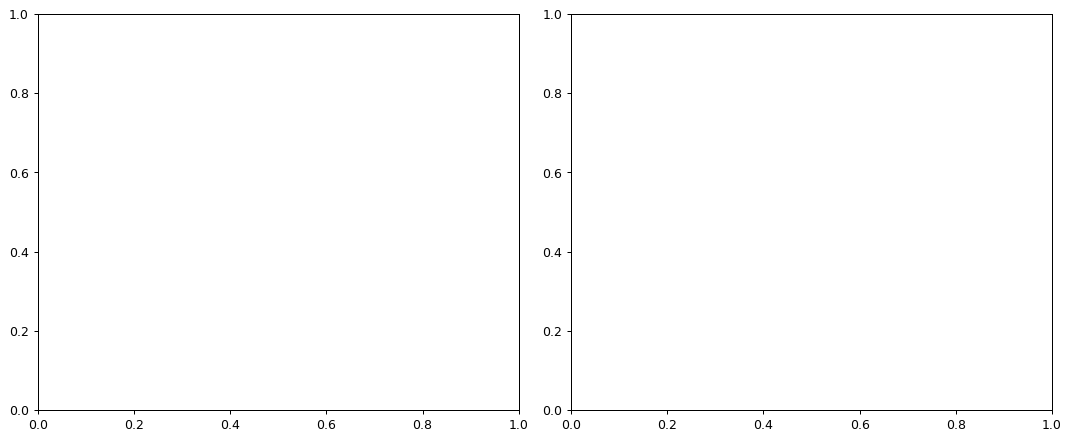

Exercice 3 a completer : comparer la frontiere polynomiale vs RBF sur make_circles


In [10]:
# Exercice 3 : noyau polynomial vs RBF sur make_circles
# TODO etudiant : generer les cercles
X_cercles = None  # TODO etudiant : remplacer (make_circles(n_samples=300, noise=0.15, factor=0.5, random_state=42)[0])
y_cercles = None  # TODO etudiant : remplacer (make_circles(...)[1])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# TODO etudiant : tracer (gauche) SVC(kernel="poly", degree=3, C=1.0, gamma="scale")
# et (droite) SVC(kernel="rbf", C=1.0, gamma="scale") sur (X_cercles, y_cercles)
# via frontiere_decision(..., ax=axes[0/1], titre=...)
plt.tight_layout()
plt.show()

print("Exercice 3 a completer : comparer la frontiere polynomiale vs RBF sur make_circles")

## Synthèse : non paramétrique supervisé vs le reste du socle

Les **SVM** (noyaux linéaire, RBF, polynomial) et le **k-NN** complètent la famille supervisée du socle ML. Là où la régression logistique (2.3) et les arbres peu profonds tracent des frontières simples, les SVM à noyau et le k-NN suivent des structures **non linéaires complexes** sans supposer de forme paramétrique. Le concept-phare de ce notebook — le **kernel trick** — montre qu'un séparateur linéaire dans un espace transformé produit une frontière courbe dans l'espace d'origine : la capacité du modèle à « courber » n'est pas ajoutée au modèle, elle vient du changement d'espace.

**Repères transverses** :

- Le notebook [2.6](2.6-Clustering-KMeans-PCA.ipynb) traitait du **non supervisé** (KMeans, ACP) : aucun label. Ici, les labels sont **connus** — c'est la distinction supervision/non-supervision, orthogonale au paramétrique/non-paramétrique.
- Comme pour tout modèle basé sur les distances (k-NN, SVM RBF), la **standardisation** est non négociable — c'est la leçon de la section 5.
- SVM et k-NN restent pertinents dans les pipelines agentic qui suivront : ce sont des références solides, interprétables géométriquement, contre lesquelles juger ce qu'un agent LLM produira comme classifieur.

> **Référence.** Vapnik, V. (1998), *Statistical Learning Theory*, Wiley. Cadre théorique des SVM : minimisation structurelle du risque, marge et bornes de généralisation.

Avec ce notebook, la série `02-ML-Cours` couvre désormais l'essentiel des grandes familles : modèles **linéaires** (2.3), **arbres et ensembles** (2.4), **modèles non paramétriques à noyaux et par distance** (2.7), sans oublier l'évaluation rigoureuse (2.5) et le non supervisé (2.6). La suite logique est l'utilisation de ce socle comme **référent jugeable** des labs agentic (`PythonAgentsForDataScience`, `AgenticDataScience`).

## References

1. Cortes, C. & Vapnik, V. (1995). *Support-Vector Networks*. Machine Learning 20(3):273-297. — Les SVM pour la classification : hyperplan à marge maximale, vecteurs supports, introduction des noyaux.
2. Vapnik, V. (1998). *Statistical Learning Theory*. Wiley. — Cadre théorique des SVM : minimisation structurelle du risque, bornes de généralisation fondées sur la marge.
3. Cristianini, N. & Shawe-Taylor, J. (2000). *An Introduction to Support Vector Machines and Other Kernel-based Learning Methods*. Cambridge University Press. — Présentation pédagogique du kernel trick et des noyaux (linéaire, polynomial, RBF).
4. Cover, T. & Hart, P. (1967). *Nearest Neighbor Pattern Classification*. IEEE Transactions on Information Theory 13(1):21-27. — La règle du 1-plus-proche-voisin et sa borne d'erreur asymptotique (≤ 2× l'erreur de Bayes).
5. Hastie, T., Tibshirani, R. & Friedman, J. (2009). *The Elements of Statistical Learning*. Springer (2e éd.), §§12.2-12.3. — SVM, noyaux et méthodes basées sur les voisins (k-NN).
6. Pedregosa, F. et al. (2011). *Scikit-learn: Machine Learning in Python*. Journal of Machine Learning Research 12:2825-2830. — `SVC`, `KNeighborsClassifier`, `StandardScaler`, `make_moons`, `make_circles`, `load_breast_cancer`.